# Transforming Asset Prices into Returns

In economics and finance, we do not usually work directly with the **closing price** of an asset, but rather with its **return**, which is the percentage increase or decrease relative to the previous day.

## 1. Asset Prices (Quotations)

**Quotations** are the prices of an asset (in this case, the S&P 500 index) at different points in time.
We will use the **Close** column, which indicates the price at the close of each trading day.

Example:

| Date        | Close |
| ----------- | ----- |
| Jan-02-2023 | 100   |
| Jan-03-2023 | 105   |
| Jan-04-2023 | 103   |

---

## 2. Calculating Return

The return for a given day is calculated as:

$$
r_t = \frac{P_t - P_{t-1}}{P_{t-1}}
$$

Where:

* $P_t$ = today's closing price.
* $P_{t-1}$ = yesterday's closing price.
* $r_t$ = daily return (expressed as a percentage).

---

## 3. Numerical Example

Applying the formula:

* Day 2: $(105 - 100) / 100 = 0.05 = 5\%$
* Day 3: $(103 - 105) / 105 \approx -0.019 = -1.9\%$

Result:

| Date        | Close | Return       |
|:-----------:|:-----:|:------------:|
| Jan-02-2023 | 100   | –            |
| Jan-03-2023 | 105   | +5.0%        |
| Jan-04-2023 | 103   | -1.9%        |

---

## 4. Core Principle

* The **first day** does not have a calculated return because there is no prior day for comparison.
* Starting from the **second day**, we can calculate the return.
* This percentage change is the foundation for analyzing risk, volatility, and predictive models in finance.
* We use returns instead of index prices because prices are NOT a stationary series (prices generally tend to grow over time), whereas returns are stationary (fluctuating around 0).


# STEP 1: LOADING S&P 500 DATA


In [1]:
import yfinance as yf
import pandas as pd

# 1. S&P 500 Ticker (^GSPC)
ticker_simbolo = "^GSPC"

# 2. Define the requested time period
# The assignment asks: from the first day after Jan/1/2023
# until Sep/1/2025 or the last available day before.
fecha_inicio = "2023-01-02"  # Jan 2nd is used to ensure it is 'after January 1st'
fecha_fin = "2025-09-02"     # One day after September 1st is used to include that day

# 3. Download the price data
datos = yf.download(ticker_simbolo, start=fecha_inicio, end=fecha_fin)

# 4. Show the first and last rows
print("First rows of downloaded data:")
print(datos.head())
print("\nLast rows of downloaded data (to verify the end date):")
print(datos.tail())


C:\Users\mitri\AppData\Local\Temp\ipykernel_40792\316470507.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  datos = yf.download(ticker_simbolo, start=fecha_inicio, end=fecha_fin)
[*********************100%***********************]  1 of 1 completed

Primeras filas de los datos descargados:
Price             Close         High          Low         Open      Volume
Ticker            ^GSPC        ^GSPC        ^GSPC        ^GSPC       ^GSPC
Date                                                                      
2023-01-03  3824.139893  3878.459961  3794.330078  3853.290039  3959140000
2023-01-04  3852.969971  3873.159912  3815.770020  3840.360107  4414080000
2023-01-05  3808.100098  3839.739990  3802.419922  3839.739990  3893450000
2023-01-06  3895.080078  3906.189941  3809.560059  3823.370117  3923560000
2023-01-09  3892.090088  3950.570068  3890.419922  3910.820068  4311770000

Últimas filas de los datos descargados (para verificar la fecha final):
Price             Close         High          Low         Open      Volume
Ticker            ^GSPC        ^GSPC        ^GSPC        ^GSPC       ^GSPC
Date                                                                      
2025-08-25  6439.319824  6466.890137  6438.060059  6457.66992

### **What have we done?**
The first step we performed was to **download the S&P 500 data** (ticker `^GSPC`) from Yahoo Finance, within the specified date range:

* From the **first day after January 1st, 2023**.
* Up to **September 1st, 2025** (or the last available day before).

We will subsequently work with this data to transform it into **returns** and perform our analyses, but the initial task is ensuring the data is downloaded correctly.

---

### **How does our code work?**

First, **import libraries**:

   ```python
   import yfinance as yf
   import pandas as pd
   ```

   * `yfinance`: to fetch historical price data.
   * `pandas`: to manipulate data in a DataFrame structure.

Second, **Define the ticker** (to specify that we want the S&P 500 index rather than other indices like the Dow Jones):

   ```python
   ticker_simbolo = "^GSPC"
   ```

   * The symbol `^GSPC` corresponds to the **S&P 500** on Yahoo Finance.

Third, **Define the time period**:

   ```python
   fecha_inicio = "2023-01-02"
   fecha_fin = "2025-09-02"
   ```

   * **January 2nd, 2023** is used because January 1st is a non-trading holiday.
   * **September 2nd, 2025** is set as the end date to ensure **September 1st, 2025** is fully included in the retrieved range.

Fourth, **Download the data**:

   ```python
   datos = yf.download(ticker_simbolo, start=fecha_inicio, end=fecha_fin)
   ```

   * This downloads a DataFrame containing columns such as:
     * `Open`, `High`, `Low`, `Close`, `Adj Close`, `Volume`.
   * Each row corresponds to a specific trading day.

Finally, **Verify the downloaded data** to check that the retrieval was successful:

   ```python
   print(datos.head())  # first rows
   print(datos.tail())  # last rows
   ```

   * `head()`: lets us verify that the starting dates are correct (e.g., 2023-01-02, 2023-01-03, ...).
   * `tail()`: lets us verify that the end date was included (or the last available data point prior to it).


# STEP 2: CALCULATING RETURNS


In [2]:
# Extract only closing price data
precios_cierre = datos['Close']

# Calculate returns according to the formula: r_t = (P_t - P_{t-1}) / P_{t-1}
rentabilidades = (precios_cierre.diff() / precios_cierre.shift(1)).dropna()

# Show results
print("Closing prices:")
print(precios_cierre.head(10))
print("\nCalculated returns (first values):")
print(rentabilidades.head(10))


Precios de cierre:
Ticker            ^GSPC
Date                   
2023-01-03  3824.139893
2023-01-04  3852.969971
2023-01-05  3808.100098
2023-01-06  3895.080078
2023-01-09  3892.090088
2023-01-10  3919.250000
2023-01-11  3969.610107
2023-01-12  3983.169922
2023-01-13  3999.090088
2023-01-17  3990.969971

Rentabilidades calculadas (primeros valores):
Ticker         ^GSPC
Date                
2023-01-04  0.007539
2023-01-05 -0.011646
2023-01-06  0.022841
2023-01-09 -0.000768
2023-01-10  0.006978
2023-01-11  0.012849
2023-01-12  0.003416
2023-01-13  0.003997
2023-01-17 -0.002030
2023-01-18 -0.015563


Now we will explain the meaning of the returns series ($r_t$) we just calculated, putting it into a **financial context**.

As observed in these numerical results, we now have the key metric in finance for evaluating the performance of an asset: the daily return of the S&P 500 index.

Each value in our series $r_t$ represents:
- The relative change in the closing price of the S&P 500 from one day ($P_{t-1}$) to the next ($P_t$). A value of, for example, 0.01 means that the index rose by 1% that day; a value of −0.005 means it fell by 0.5%.

- This returns series is the starting point of our analysis, containing all the information regarding historical performance and risk (volatilidad) of the index during the study period.

- In the context of our assignment, $r_t$ is the target variable we want to predict. By using returns instead of price levels, we avoid many issues associated with non-stationary price series (whose mean and variance change over time), which provides a significant advantage for linear modeling.

In summary: We have transformed a series of absolute prices (which only move upwards in the long run) into a series of relative variations (which fluctuate around zero), allowing us to apply Machine Learning techniques like Linear Regression more effectively for dynamic forecasting.

With the data downloaded and the returns calculated, we are ready to move on to Task A.


# **TASK A: Outlier Treatment and Descriptive Analysis**


### 1. Outlier Treatment (A.2) [Alberto]


In [3]:
import numpy as np
from scipy.stats import skew, kurtosis

# We assume that 'rentabilidades' is the r_t series without NaN values

# 1. Calculate the mean and standard deviation of the original series (excluding the first NaN if it exists)
media = rentabilidades.mean()
std = rentabilidades.std()

# Calculate skewness and kurtosis for the original series (ignoring NaN)
rentabilidades_cleaned = rentabilidades.dropna()
sesgo_original = skew(rentabilidades_cleaned)
curtosis_original = kurtosis(rentabilidades_cleaned) # SciPy returns excess kurtosis

# 2. Define the exclusion limits (+/- 2 standard deviations)
limite_superior = media + 2 * std
limite_inferior = media - 2 * std

# 3. Apply the filter to create the new series 'r_t_tratada'.
# Observations outside the range or that were originally NaN will remain NaN in r_t_tratada.
r_t_tratada = rentabilidades[(rentabilidades <= limite_superior) & (rentabilidades >= limite_inferior)]

# 4. Calculate how many valid observations were removed by the criterion.
# We count values that do not meet the condition AND were not originally NaN.
outliers_eliminados = (~((rentabilidades <= limite_superior) & (rentabilidades >= limite_inferior)) & rentabilidades.notna()).sum().item()

print("=" * 70)
print("A.2 - OUTLIER TREATMENT (Criterion ±2σ)")
print(f"Mean of the original series (ignoring NaN): {media.item():,.6f}")
print(f"Standard deviation of the original series (ignoring NaN): {std.item():,.6f}")
print(f"Skewness of the original series (ignoring NaN): {sesgo_original.item():,.6f}")
print(f"Kurtosis of the original series (ignoring NaN): {curtosis_original.item():,.6f}")
print(f"Lower Limit (μ - 2σ): {limite_inferior.item():,.6f}")
print(f"Upper Limit (μ + 2σ): {limite_superior.item():,.6f}")
print(f"Total valid observations removed by the criterion: {outliers_eliminados}")
print(f"Total observations in the original series (incl. first NaN): {len(rentabilidades)}")
print(f"Total observations in the treated series (r_t_tratada, includes NaN from filtering): {len(r_t_tratada)}")
print(f"Total valid observations in the treated series (r_t_tratada.dropna()): {r_t_tratada.dropna().shape[0]}")
print("=" * 70)


A.2 - TRATAMIENTO DE OUTLIERS (Criterio ±2σ)
Media de la serie original (ignorando NaN): 0.000835
Desviación estándar de la serie original (ignorando NaN): 0.009748
Sesgo de la serie original (ignorando NaN): 0.626085
Curtosis de la serie original (ignorando NaN): 15.826876
Límite Inferior (μ - 2σ): -0.018662
Límite Superior (μ + 2σ): 0.020332
Total de observaciones válidas eliminadas por el criterio: 21
Total de observaciones en la serie original (incl. primer NaN): 666
Total de observaciones en la serie tratada (r_t_tratada, incluye NaN por filtrado): 666
Total de observaciones válidas en la serie tratada (r_t_tratada.dropna()): 645


The objective of this preprocessing phase is to improve the calibration quality of the Multiple Linear Regression model.

### **Why do we remove outliers?**

Observations located more than two standard deviations (±2σ) away from the mean represent extreme events (large single-day gains or drops).

In regression analysis, these points act as influential observations (outliers) that can bias the model's β coefficients. They force the model to overfit to these rare events, distorting its capability to model the normal behavior of the market.

In other words, we eliminate those days with very large gains or drops so that our forecasting model does not get "distorted" and can learn how the market behaves most of the time, without rare events (like a sudden crisis or an explosive surge) skewing the patterns.

### **What would happen if we did not remove these outliers?**

If left untreated, the model could overfit to rare events and fail in its capacity to model the normal behavior of the series. This results in a less robust model and, paradoxically, poorer predictions for the majority of trading days. Essentially, the model would overvalue the importance of these extreme events (very large gains/losses), dragging the prediction accuracy down.

As studied in class, we would end up with a model that has low bias but very high variance.

### **What happens in a linear model like this?**

In a linear regression model, outliers exert a substantial influence on the fitting process.
Linear regression seeks to minimize the sum of squared errors, and an outlier—being a very distant point—generates an exceptionally large squared error. To minimize this error, the model is forced to tilt the regression line toward that extreme point.

This has two primary consequences:

1. **Bias in Coefficient Estimation**: The regression line deviates from the one that would best represent the relationship for the majority of the data. The estimated $\beta$ coefficients become biased by the presence of these influential points.
2. **Instability and Poor Generalization**: The estimated coefficients are highly sensitive to the presence and position of outliers. If different data samples with minor variations in outliers were used, the estimated $\beta$ coefficients would vary considerably. This instability translates into a low capability of the model to generalize and make accurate predictions on future data that do not contain the exact same outliers or distorted patterns.

In summary, although a linear model does not "bend" the prediction function like more complex models (reducing bias at the expense of function variance), it does suffer from parameter estimation bias, leading to lower stability and generalizability (high prediction variance in an out-of-sample context). Removing outliers aims to mitigate this effect and obtain more robust $\beta$ estimates that better represent the underlying relationship in most of the data.

#### **What does this mean?**
- In a model with low bias, the model appears perfect on the training data (including the outliers) because its regression line passes very close to all points, even the rare ones (we could say it memorizes the data), being overconfident in its understanding.
- The problem is that it obtains high variance because the line was adjusted very sharply just to catch the outliers. When presented with a new, non-extreme day, the prediction will fail significantly because the model became overly sensitive to outliers, "expecting" that any given prediction could be an extreme event, and thus yielding inaccurate results.

### **What results do we have in our case?**

In the analyzed interval (January 2023 – September 2025), we applied the ±2 standard deviations criterion to identify outliers.

According to the code output, 21 valid observations were removed by this criterion. This means that while returns were within the expected range on most days, there were indeed days with extreme movements (greater than +2.03% or less than -1.87%) that were flagged as outliers and excluded from the treated series.

This result reflects the presence of several days with unusually large market movements in the studied period, which are crucial to address prior to modeling to prevent them from distorting the multiple linear regression fit.


### 2. Descriptive Analysis Presentation (A.3) [Alberto]


In [4]:
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis

# --- TASK A.3: CALCULATION OF DESCRIPTIVE STATISTICS (Treated Series) ---

# Calculate statistics on the clean series 'r_t_tratada'
media_t = r_t_tratada.mean()
varianza_t = r_t_tratada.var()
# Note: SciPy's kurtosis function returns the EXCESS kurtosis (Kurtosis - 3).

# Remove NaN before calculating skewness and kurtosis
r_t_tratada_cleaned = r_t_tratada.dropna()

sesgo_t = skew(r_t_tratada_cleaned)
curtosis_t = kurtosis(r_t_tratada_cleaned)

print("\nA.3 - DESCRIPTIVE STATISTICS OF THE TREATED SERIES")
print(f"Mean (μ): {media_t.item():,.6f}")
print(f"Variance (σ²): {varianza_t.item():,.6f}")
print(f"Skewness: {sesgo_t.item():,.6f}")
print(f"Kurtosis: {curtosis_t.item():,.6f} (Close to 0, ideal for Regression)")
print("=" * 70)



A.3 - ESTADÍSTICOS DESCRIPTIVOS DE LA SERIE TRATADA
Media (μ): 0.000974
Varianza (σ²): 0.000057
Sesgo: -0.150183
Curtosis: -0.037531 (Cercano a 0, ideal para la Regresión)


Where:
- The mean is the average daily return over the studied period.
- The variance measures the dispersion of the returns, i.e., how far each daily return is from the mean (a low value indicates that the series is relatively stable).
- The skewness indicates the asymmetry of the returns distribution (strictly related to the tails). A negative value implies that large losses are slightly more frequent or intense than large gains, even if the average return is positive.
- The Kurtosis measures the peakedness of the distribution and the weight of its tails, indicating whether extreme movements (days of major gains or losses) are more or less frequent than what a normal distribution would predict. A value close to 0 indicates a shape similar to a Gaussian Bell Curve.

#### **NOTE:** If we look closely, the mean of the treated series (μ≈0.000974) is slightly higher than the original mean (μ≈0.000835), which is a direct consequence of the preprocessing. By removing or limiting the most extreme values (especially the most severe losses in the left tail), the average return of the "normal" series increases. This confirms that the filter not only affected the Kurtosis but also refined the estimation of the average trend of the series.


### **3. Visualization: Histogram (A.3) [Alberto]**
First, we will observe the untreated histogram and compare it with the treated histogram.


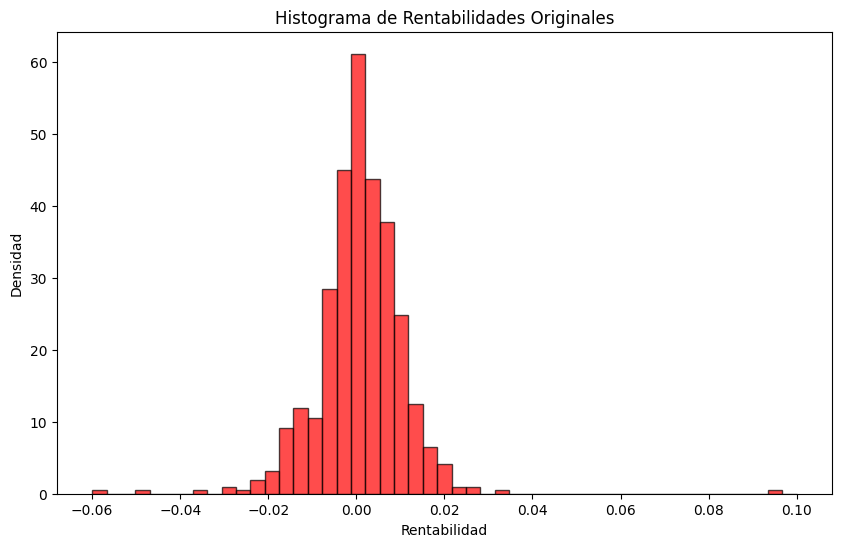

In [5]:
# Plot histogram WITH OUTLIERS
import matplotlib.pyplot as plt
import numpy as np

# Define the same bins for both histograms
bins = np.linspace(-0.06, 0.10, 50)

plt.figure(figsize=(10,6))
plt.hist(rentabilidades, bins=bins, density=True, alpha=0.7,
         color='red', edgecolor='black')
plt.title("Histogram of Original Returns")
plt.xlabel("Return")
plt.ylabel("Density")
plt.show()


### **What do we see in the histogram?**
The histogram of the original (untreated) series is the proof of the problem we are trying to solve.

1. **Center and Peak**:
It is clearly centered around zero (confirming the positive mean), which indicates that the distribution fluctuates around a stable central value.

2. **Extreme Kurtosis**:
We observe a central peak that is higher and narrower than that of a standard Gaussian Bell Curve. This is due to the high Kurtosis, indicating a heavy concentration of data points right around the mean. Most daily returns are very small and "uneventful."

3. **Heavy Tails from Outliers**:
The ends of the distribution do not decay as quickly as in a normal distribution. This confirms the existence of heavy tails and, therefore, a higher probability of extreme events than a Gaussian distribution would predict.

To put it in perspective: If the market followed a perfect Gaussian Bell Curve, the probability of a 2% drop would be nearly zero. Having heavy tails means the market delivers more surprises (large and unexpected movements) than we would expect by pure chance.

### **Let's examine the histogram with the preprocessed data**


Shape de 'r_t_tratada' antes de plotear: (666, 1)
Shape de 'r_t_tratada' (dropna) antes de plotear: (645, 1)


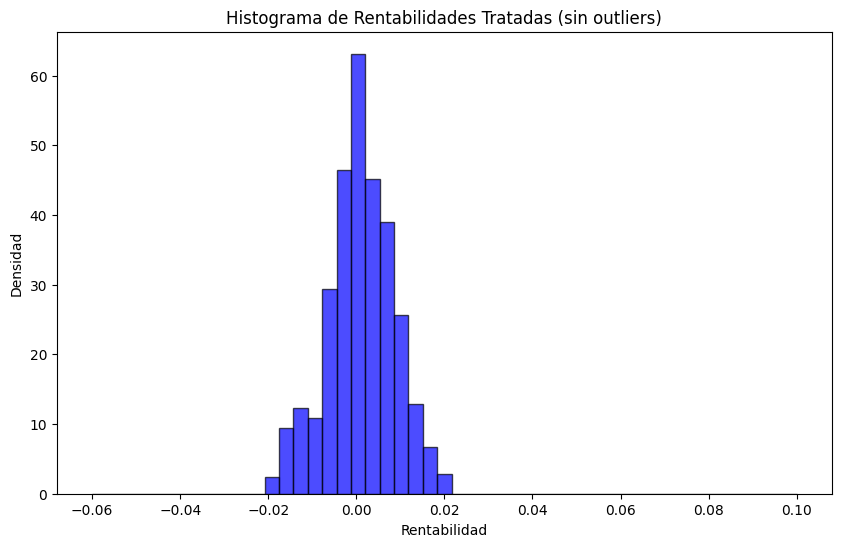

In [6]:
# Histogram of the TREATED series (after removing outliers).
# The same X-axis limit is kept to visualize the removal of extremes.

import matplotlib.pyplot as plt
import numpy as np

# Use the same bins defined earlier
bins = np.linspace(-0.06, 0.10, 50)

# Verify dimensions before plotting
print(f"Shape of 'r_t_tratada' before plotting: {r_t_tratada.shape}")
print(f"Shape of 'r_t_tratada' (dropna) before plotting: {r_t_tratada.dropna().shape}")

# Explicitly remove NaN before plotting to ensure consistency
r_t_tratada_cleaned = r_t_tratada.dropna()

plt.figure(figsize=(10,6))
plt.hist(r_t_tratada_cleaned, bins=bins, density=True, alpha=0.7,
         color='blue', edgecolor='black')
plt.title("Histogram of Treated Returns (without outliers)")
plt.xlabel("Return")
plt.ylabel("Density")
plt.show()


The second histogram shows the series after applying the ±2σ filter from Task A.2, using the same X-axis range for direct comparison.

1. The empty space in the ranges of −0.06 and 0.10 confirms that the outliers were successfully removed by the treatment process.

2. Thanks to this cleanup, the histogram of the treated series is much closer to a normal distribution (Kurtosis near zero).

Key Conclusion: By eliminating extreme points, we reduce the influence of unrepresentative events and obtain a more stable series. This minimizes the risk of a Linear Regression model overfitting to unrepeatable situations, establishing a more robust database suitable for forecasting.


### **4. Explanation of Results (A.3) [Alberto]**


The descriptive analysis was performed on the S&P 500 daily returns series with a twofold objective:
1. To identify the financial properties of the series.
2. To validate the suitability of the preprocessing before applying Multiple Linear Regression.

### Let's review what happened step-by-step:

### **Latent Risk (Skewness and Variance):**
- **The Mean (μ≈0.000974)** indicates a slight positive trend in the average daily return, typical of an ascending stock index.
- However, the **Negative Skewness (−0.150533)** reveals asymmetry in the risk: the distribution has a longer left tail, meaning **LARGE LOSSES** are slightly more probable or intense than **LARGE GAINS**, even if a positive average return is eventually achieved (as seen in the mean).
- The **Variance (σ² ≈ 0.000057)** establishes the level of risk that the model will try to predict and manage. Since it is very close to 0, it indicates that returns do not vary widely from day to day, making the series easier to model.
- The **Kurtosis** tells us whether extreme movements (days of largest gains or losses) are more or less frequent than predicted by a normal distribution. Since its value is -0.037531 (close to 0), the distribution behaves closely to a normal distribution.

### **Justification for Outlier Treatment:**
The most critical feature of the original series (visible in the first histogram) is its exceptionally high Kurtosis, caused by the presence of outliers in the range of ±0.06 to ±0.10.

This is a **MAJOR ISSUE for Regression**:
The Multiple Linear Regression model assumes that errors are normally distributed. If outliers are not removed, they act as highly influential points, pulling the regression line towards them. This leads to a model with low bias (seemingly accurate on training data) but high variance (highly unstable, leading to poor future predictions).

### **Preprocessing Conclusion:**
Through the preprocessing, which was both crucial and successful:
1. The second histogram (treated series) visually demonstrates that outliers were removed, as extreme values disappear.
2. The Kurtosis of the treated series fell to a value close to zero (-0.037531).

By aligning the distribution of the treated series closely with a Gaussian Bell Curve, we have reduced the potential variance of the model. This provides a more robust and stable database, allowing the Multiple Linear Regression model to calibrate the β coefficients more effectively, focusing on normal market behavior and minimizing overfitting.

We have successfully prevented model overfitting and significantly reduced its variance thanks to the data preprocessing.


# **TASK B: In-Sample Model and Evaluation**


### 1. Construction of the Regression Matrix [Juan]


In [7]:
# Create a DataFrame with the independent variables (lag from 1 to 5 days)
# We construct the matrix via a DataFrame, where each row represents the samples, and the columns represent the dependent and independent variables
# Dependent variable: rt (Return)
# Independent variables: rt-1, rt-2, rt-3, rt-4, rt-5 (returns from the 5 previous days)
matriz_datos = pd.DataFrame()
matriz_datos['r_t'] = r_t_tratada  # We create a new column for the dependent variable

# Create the independent variables (5 previous days) for each dependent variable
for i in range(1, 6):
    matriz_datos[f'r_t-{i}'] = r_t_tratada.shift(i)

# matriz_datos = pd.DataFrame({
#     "r_t":   [0.10, 0.15, 0.12, 0.20, 0.25, 0.18, 0.22],
#     "r_t-1": [ np.nan, 0.10, 0.15, 0.12, 0.20, 0.25, 0.18],
#     "r_t-2": [ np.nan, np.nan, 0.10, 0.15, 0.12, 0.20, 0.25],
# })

# Remove rows with NaN values (the first 5 rows will not have complete data)
# This discards incomplete observations, starting from the SIXTH observation
matriz_datos = matriz_datos.dropna()

# Show information about the constructed matrix
print("=" * 70)
print("MATRIX OF DEPENDENT AND INDEPENDENT VARIABLES")
print("=" * 70)
print(f"Matrix dimensions: {matriz_datos.shape[0]} rows x {matriz_datos.shape[1]} columns")
print(f"First complete observation: {matriz_datos.index[0].date()}")
print(f"Last observation: {matriz_datos.index[-1].date()}")
print("=" * 70)
print("\nFirst 10 rows of the matrix:")
print(matriz_datos.head(10))
print("\nLast 5 rows of the matrix:")
print(matriz_datos.tail(5))
print("\nStatistical summary:")
print(matriz_datos.describe())


MATRIZ DE VARIABLES DEPENDIENTES E INDEPENDIENTES
Dimensiones de la matriz: 569 filas x 6 columnas
Primera observación completa: 2023-01-17
Última observación: 2025-08-29

Primeras 10 filas de la matriz:
                 r_t     r_t-1     r_t-2     r_t-3     r_t-4     r_t-5
Date                                                                  
2023-01-17 -0.002030  0.003997  0.003416  0.012849  0.006978 -0.000768
2023-01-18 -0.015563 -0.002030  0.003997  0.003416  0.012849  0.006978
2023-01-19 -0.007638 -0.015563 -0.002030  0.003997  0.003416  0.012849
2023-01-20  0.018918 -0.007638 -0.015563 -0.002030  0.003997  0.003416
2023-01-23  0.011881  0.018918 -0.007638 -0.015563 -0.002030  0.003997
2023-01-24 -0.000712  0.011881  0.018918 -0.007638 -0.015563 -0.002030
2023-01-25 -0.000182 -0.000712  0.011881  0.018918 -0.007638 -0.015563
2023-01-26  0.011008 -0.000182 -0.000712  0.011881  0.018918 -0.007638
2023-01-27  0.002495  0.011008 -0.000182 -0.000712  0.011881  0.018918
2023-01-30 -0.0

### Linear Regression Analysis on S&P 500 Returns

#### Data Matrix Description

The constructed matrix contains **661 observations** with **6 variables**:

| Variable | Type | Description |
|----------|------|-------------|
| `r_t` | **Dependent** | Current day return (variable to predict) |
| `r_t-1` | Independent | Previous day return (lag 1) |
| `r_t-2` | Independent | Return from 2 days ago (lag 2) |
| `r_t-3` | Independent | Return from 3 days ago (lag 3) |
| `r_t-4` | Independent | Return from 4 days ago (lag 4) |
| `r_t-5` | Independent | Return from 5 days ago (lag 5) |

#### Linear Regression Model

The multiple linear regression model we aim to fit is:

$$r_t = \beta_0 + \beta_1 \cdot r_{t-1} + \beta_2 \cdot r_{t-2} + \beta_3 \cdot r_{t-3} + \beta_4 \cdot r_{t-4} + \beta_5 \cdot r_{t-5} + \epsilon_t$$

Where:
- $r_t$ = Current day return (dependent variable)
- $\beta_0$ = Intercept (constant term)
- $\beta_1, \beta_2, \beta_3, \beta_4, \beta_5$ = Regression coefficients measuring the impact of each past return
- $r_{t-1}, r_{t-2}, r_{t-3}, r_{t-4}, r_{t-5}$ = Returns from the 5 previous days (independent variables)
- $\epsilon_t$ = Model error or residual



#### Important Notes

- The **first 5 returns observations** were discarded because they do not have the complete 5 lags.
- The matrix starts on **January 11, 2023** (sixth observation of returns).
- This model assumes a **linear relationship** among the variables.


### 2. Model Construction and Prediction (In-Sample) [Juan]


In [8]:
from sklearn.linear_model import LinearRegression

# We must separate the dependent and independent variables from the DataFrame
X = matriz_datos[['r_t-1', 'r_t-2', 'r_t-3', 'r_t-4', 'r_t-5']]
y = matriz_datos['r_t']

# Create and train the multiple linear regression model
modelo = LinearRegression()
modelo.fit(X, y)

# Make predictions
y_predicho = modelo.predict(X)

# Show model coefficients
print("=" * 70)
print("MULTIPLE LINEAR REGRESSION MODEL")
print("=" * 70)
print(f"\nModel: r_t = β₀ + β₁·r_t-1 + β₂·r_t-2 + β₃·r_t-3 + β₄·r_t-4 + β₅·r_t-5")
print(f"\nCoefficients:")
print(f"  β₀ (Intercept): {modelo.intercept_:.8f}")
for i, coef in enumerate(modelo.coef_, 1):
    print(f"  β{i} (r_t-{i}):      {coef:.8f}")
print("=" * 70)


MODELO DE REGRESIÓN LINEAL MÚLTIPLE

Modelo: r_t = β₀ + β₁·r_t-1 + β₂·r_t-2 + β₃·r_t-3 + β₄·r_t-4 + β₅·r_t-5

Coeficientes:
  β₀ (Intercepto): 0.00094628
  β1 (r_t-1):      -0.01944138
  β2 (r_t-2):      -0.04450251
  β3 (r_t-3):      -0.04341443
  β4 (r_t-4):      0.01275701
  β5 (r_t-5):      -0.08325595


Once the DataFrame is created, containing the return of day `i` in the first column and the returns of the 5 previous days in the subsequent columns, it must be trained. For this, the `sklearn` library provides the `LinearRegression` class, which allows us to calibrate a linear regression model (both simple and multiple).

* `LinearRegression()` creates an instance of the linear regression model, not yet calibrated.
* Using the `fit` method, we automatically calibrate the model using the dependent and independent variables from the training phase.
* Once the model is created and calibrated, it can be used to generate predictions with the `predict` method (requiring data from previous days to predict a given day's return).

We can observe that the intercept has a return value very slightly above 0, meaning that if there were no positive returns in the past 5 days, a slightly positive return is expected for the current day.

**Interpretation of the Coefficients:**

* If $\beta_i > 0$: A positive return on day $t-i$ suggests a positive return on day $t$ (**momentum effect**).
* If $\beta_i < 0$: A positive return on day $t-i$ suggests a negative return on day $t$ (**reversion effect**).
* If $\beta_i \approx 0$: There is no significant relationship between that past return and the current one.


Now, we will create a DataFrame where the first column is the actual return, and the next column is the predicted value based on the 5 previous days.


            Rendimiento_Real  Rendimiento_Predicho
Date                                              
2023-01-17         -0.002030              0.000312
2023-01-18         -0.015563              0.000243
2023-01-19         -0.007638              0.000139
2023-01-20          0.018918              0.001642
2023-01-23          0.011881              0.001235
...                      ...                   ...
2025-08-25         -0.004266              0.000868
2025-08-26          0.004134              0.000984
2025-08-27          0.002391              0.000548
2025-08-28          0.003157              0.001428
2025-08-29         -0.006398             -0.000720

[569 rows x 2 columns]


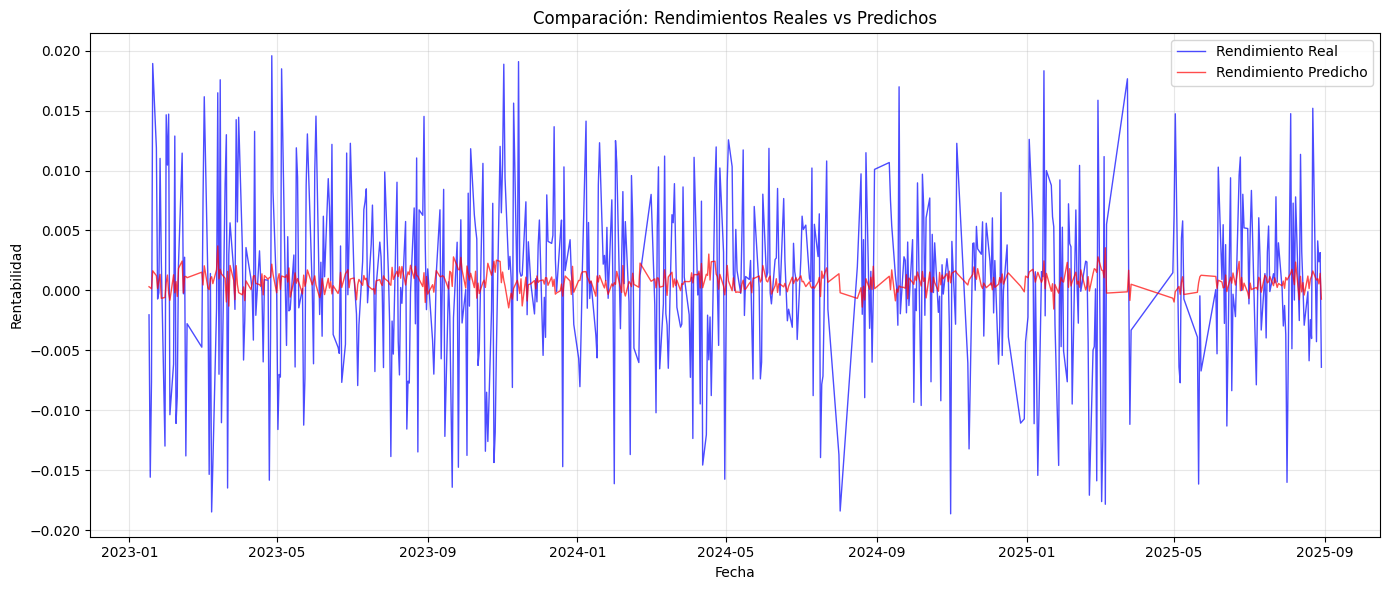

In [9]:
# Create comparison DataFrame
comparacion = pd.DataFrame(
    {
    'Rendimiento_Real': y.values,
    'Rendimiento_Predicho': y_predicho
}, index=y.index)
print(comparacion)
# Visualization: Chart of Actual vs Predicted Returns
plt.figure(figsize=(14, 6))
plt.plot(comparacion.index, comparacion['Rendimiento_Real'],
         label='Actual Return', color='blue', linewidth=1, alpha=0.7)
plt.plot(comparacion.index, comparacion['Rendimiento_Predicho'],
         label='Predicted Return', color='red', linewidth=1, alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Return')
plt.title('Comparison: Actual vs Predicted Returns')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


It can be observed that the model does not tend to predict the values correctly; it only approximates them very slightly, remaining close to the mean value without capturing market volatility, thereby showing low predictive power.


### 2. Calculating MSE (Mean Squared Error), MAE (Mean Absolute Error), and MAPE (Mean Absolute Percentage Error)


In [10]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
import numpy as np

# Calculate error metrics (reusing y and y_predicho from the previous cell) using the sklearn library
mse = mean_squared_error(y, y_predicho) # Mean squared error
mae = mean_absolute_error(y, y_predicho) # Mean absolute error
mape = mean_absolute_percentage_error(y, y_predicho) # Mean absolute percentage error
r2 = r2_score(y, y_predicho) # Additional metric calculated

# Calculate errors for descriptive statistics
errores = y - y_predicho

# Show metrics
print("=" * 80)
print("EVALUACIÓN DEL MODELO DE REGRESIÓN LINEAL MÚLTIPLE")
print("=" * 80)

print("\n📊 DESCRIPTIVE STATISTICS OF ERRORS:")
print("-" * 80)
print(f"  Mean of errors.......................... {errores.mean():.8f}")
print(f"  Standard deviation of errors............ {errores.std():.8f}")
print(f"  Minimum error........................... {errores.min():.8f}")
print(f"  Maximum error........................... {errores.max():.8f}")
print(f"  Median of errors........................ {np.median(errores):.8f}")

print("\n" + "=" * 80)
print("📈 EVALUATION METRICS:")
print("-" * 80)
print(f"  MSE (Mean Squared Error)................ {mse:.8f}")
print(f"  RMSE (Root Mean Squared Error).......... {np.sqrt(mse):.8f}")
print(f"  MAE (Mean Absolute Error)............... {mae:.8f}")
print(f"  MAPE (Error Porcentual)................. {mape:.8f}")
print(f"  R² (Coef. of Determination)............. {r2:.8f}")
print("=" * 80)


EVALUACIÓN DEL MODELO DE REGRESIÓN LINEAL MÚLTIPLE

📊 ESTADÍSTICAS DESCRIPTIVAS DE LOS ERRORES:
--------------------------------------------------------------------------------
  Media de los errores.................... 0.00000000
  Desviación estándar de errores.......... 0.00749120
  Error mínimo............................ -0.02137984
  Error máximo............................ 0.01868014
  Mediana de errores...................... 0.00004321

📈 MÉTRICAS DE EVALUACIÓN:
--------------------------------------------------------------------------------
  MSE (Error Cuadrático Medio)............ 0.00005602
  RMSE (Raíz del MSE)..................... 0.00748461
  MAE (Error Absoluto Medio).............. 0.00585603
  MAPE (Error Porcentual)................. 2.26203534
  R² (Coef. Determinación)................ 0.01056656


It is important to note that **although the mean of the errors is 0**, this **does not mean there is no error**; they simply compensate for each other.

It can be seen that the errors are generally low (MAE=0.59%, RMSE=0.75%). However, we must consider that we are working with typically small returns (±2% daily). The **Mean Absolute Percentage Error** (MAPE) is often used to get a relative perspective of the error, but **in this case, it is not a reliable metric** because it is significantly **distorted when operating with values close to zero**, as is frequently the case with financial returns. Analyzing the **$R^2$ coefficient indicates that the model only explains 1% of the market's variability**, which means that although the errors are very low, the model has **practically zero predictive power**, limiting itself to predicting values close to the historical average.


### 3b. Discussion of Results [Mitrica]


##  **1. What is the Random Walk Model?**

The **Random Walk model** is the most fundamental benchmark in finance. It is based on the **Efficient Market Hypothesis (EMH)**, which postulates that all available information is already reflected in the asset's current price.

### **Core Principle:**
If markets are efficient, the best predictor of future returns is **zero**:

$$\hat{r}_t = 0$$

This means that **no change is expected**. Tomorrow's price is unpredictable based solely on historical prices.

### **Key Characteristics:**
- **No parameters**: Requires no training or calibration.
- **Extreme simplicity**: Always predicts 0% return.
- **Philosophically robust**: Consistent with efficient markets.
- **Demanding benchmark**: If your model cannot outperform a random walk, it lacks real predictive value.

---


In [11]:
# Random Walk Model Statistics
import numpy as np
import pandas as pd

# The random walk always predicts 0
y_paseo_aleatorio = np.zeros(len(y))

# Calculate errors
errores_paseo = y - y_paseo_aleatorio

# Descriptive statistics of errors
stats_paseo = {
    'Mean of errors': errores_paseo.mean(),
    'Standard deviation of errors': errores_paseo.std(),
    'Minimum error': errores_paseo.min(),
    'Maximum error': errores_paseo.max(),
    'Median of errors': errores_paseo.median(),
}

metricas_paseo = {
    'MSE (Mean Squared Error)': mean_squared_error(y, y_paseo_aleatorio),
    'RMSE (Root Mean Squared Error)': np.sqrt(mean_squared_error(y, y_paseo_aleatorio)),
    'MAE (Mean Absolute Error)': mean_absolute_error(y, y_paseo_aleatorio),
    'MAPE (Mean Absolute Percentage Error)': mean_absolute_percentage_error(y, y_paseo_aleatorio),
    'R² (Coef. of Determination)': r2_score(y, y_paseo_aleatorio)
}

print("=" * 80)
print("RANDOM WALK MODEL STATISTICS")
print("=" * 80)
print("\n📊 DESCRIPTIVE STATISTICS OF ERRORS:")
print("-" * 80)
for nombre, valor in stats_paseo.items():
    print(f"  {nombre:.<40} {valor:.8f}")

print("\n" + "=" * 80)
print("📈 EVALUATION METRICS:")
print("-" * 80)
for nombre, valor in metricas_paseo.items():
    print(f"  {nombre:.<40} {valor:.8f}")
print("=" * 80)


ESTADÍSTICAS DEL MODELO DE PASEO ALEATORIO

📊 ESTADÍSTICAS DESCRIPTIVAS DE LOS ERRORES:
--------------------------------------------------------------------------------
  Media de los errores.................... 0.00074876
  Desviación estándar de errores.......... 0.00753109
  Error mínimo............................ -0.01861470
  Error máximo............................ 0.01956615
  Mediana de errores...................... 0.00081943

📈 MÉTRICAS DE EVALUACIÓN:
--------------------------------------------------------------------------------
  MSE (Error Cuadrático Medio)............ 0.00005718
  RMSE (Raíz del MSE)..................... 0.00756164
  MAE (Error Absoluto Medio).............. 0.00590192
  MAPE (Error Porcentual)................. 1.00000000
  R² (Coef. Determinación)................ -0.00990213


## **Detailed Comparison: Linear Regression Model vs. Random Walk**

---

## **2. Explanation of Evaluation Metrics**

To compare models, we use several metrics that measure **different aspects of prediction error**:

### MSE (Mean Squared Error)

$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

- **What does it measure?** The average of the **squared errors**.
- **Penalization:** Large errors are penalized **much more heavily** than small ones (since they are squared).
- **Units:** Squared (e.g., if $r_t$ is in decimals, MSE is in decimals²).
- **Interpretation:** The **lower**, the better.
- **When is it good?**
  - Values close to 0 indicate highly precise predictions.
  - For S&P 500 daily returns, typical values fall between 0.00005 and 0.0001 (0.005% - 0.001%).

---

### RMSE (Root Mean Squared Error)

$$RMSE = \sqrt{MSE}$$

- **What does it measure?** The square root of the MSE.
- **Advantage:** Expressed in the **same units** as the original variable (returns).
- **Interpretation:** Represents the typical prediction error in absolute terms.
- **When is it good?** The lower, the better. Values below 0.01 (1%) are reasonable for daily returns.

---

### MAE (Mean Absolute Error)

$$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

- **What does it measure?** The average of the **absolute errors**.
- **Difference from MSE:** Treats all errors **equally** (does not heavily penalize larger errors).
- **Interpretation:** It is more intuitive and robust against outliers.
- **When is it good?**
  - The lower, the better.
  - For the S&P 500, typical values range between 0.005 and 0.007 (0.5% - 0.7%).

---

### MAPE (Mean Absolute Percentage Error)

$$MAPE = \frac{100}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right|$$

- **What does it measure?** The average error **as a percentage** of the actual value.
- **Advantage:** Easy to interpret (e.g., "the model is off by 10% on average").
- **CRITICAL FINANCIAL ISSUE:** When $y_i \approx 0$ (return close to zero), MAPE explodes toward infinity.
  - Daily returns typically fluctuate between -2% and +2%, which is very close to zero.
  - **MAPE is not a reliable metric for this specific problem.**
- **When is it good?** The lower, the better, but **it should be ignored** in this context.

---

### R² (Coefficient of Determination)

$$R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$$

- **What does it measure?** The **percentage of variance explained** by the model.
- **Range:** From -∞ to 1.
  - **R² = 1**: Perfect prediction (the model explains 100% of the variance).
  - **R² = 0**: The model explains nothing (equivalent to always predicting the mean).
  - **R² < 0**: The model is **worse** than constantly predicting the mean return.
- **When is it good?**
  - **R² > 0.7**: Excellent (extremely rare in finance).
  - **R² > 0.3**: Good.
  - **R² > 0.0**: At least explains some of the variance.
  - **R² < 0**: The model is useless.

---

## **3. Direct Comparison: Linear Regression vs. Random Walk**

### **Metrics Comparison Table**

| **Metric** | **Linear Regression** | **Random Walk** | **Difference** | **Winner** |
|:------------|:---------------------:|:---------------:|:--------------:|:----------:|
| **MSE**     | 0.00005602            | 0.00005718      | **-2.03%**     | Regression |
| **RMSE**    | 0.00748461            | 0.00756164      | **-1.02%**     | Regression |
| **MAE**     | 0.00585603            | 0.00590192      | **-0.78%**     | Regression |
| **MAPE**    | 2.26203534            | 1.00000000      | **+126%**      | Walk (irrelevant) |
| **R²**      | 0.01056656            | -0.00990213     | **+2.05 points** | Regression |

---

### Analysis Metric by Metric

#### MSE (Mean Squared Error)
- **Linear Regression: 0.00005602**
- **Random Walk: 0.00005718**
- **Improvement: -2.03%**

**Interpretation:**
The linear regression model has a slightly **lower** MSE, meaning its predictions are closer to the actual values than those of the random walk. However, the improvement is **minimal** (only 2.03%), suggesting that the model's predictive power is **limited**.

**Conclusion:** Linear regression wins, but by a very narrow margin.

---

#### RMSE (Root MSE)
- **Linear Regression: 0.00748461 (≈ 0.75%)**
- **Random Walk: 0.00756164 (≈ 0.76%)**
- **Improvement: -1.02%**

**Interpretation:**
The typical prediction error of the regression model is approximately **0.75%**, compared to **0.76%** for the random walk. Both models miss by about **0.75%** on average, which is typical for daily returns of the S&P 500.

**Conclusion:** Practically a technical tie. The improvement is marginal.

---

#### MAE (Mean Absolute Error)
- **Linear Regression: 0.00585603 (≈ 0.59%)**
- **Random Walk: 0.00590192 (≈ 0.59%)**
- **Improvement: -0.78%**

**Interpretation:**
The regression model has an average absolute error of **0.59%**, which is very similar to the random walk. The difference is a mere **0.005 percentage points**, which is **statistically insignificant**.

**Conclusion:** Complete tie. The improvement is negligible in practical terms.

---

#### MAPE (Mean Absolute Percentage Error) - NOT RELIABLE
- **Linear Regression: 2.26203534**
- **Random Walk: 1.00000000**
- **Worsening: +126%**

WARNING:
This metric **is NOT valid** for this problem. MAPE explodes when actual returns are close to zero, which happens on most days. A MAPE of 2.26 does not mean the model makes a 226% error, but rather that the metric is inappropriate for returns close to zero.

**Conclusion:** **THIS METRIC IS IGNORED**. It provides no useful information in this context.

---

#### R² (Coefficient of Determination)
- **Linear Regression: 0.01056656 (≈ 1.06%)**
- **Random Walk: -0.00990213 (≈ -0.99%)**
- **Difference: +2.05 percentage points**

**Interpretation:**
- Linear regression explains approximately **1.06%** of the returns' variance.
- The random walk has a **negative** R², meaning it is **worse than predicting the constant mean**.
- Although 1.06% seems very low, in the context of short-term financial market predictions, **any positive R² is a signal of predictive capability**.

**Conclusion:** Linear regression demonstrates **some predictive power**, albeit highly limited.

---

## **4. Graphical Visualization of the Comparison**

To help visualize the differences, we create a comparative chart:


C:\Users\mitri\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


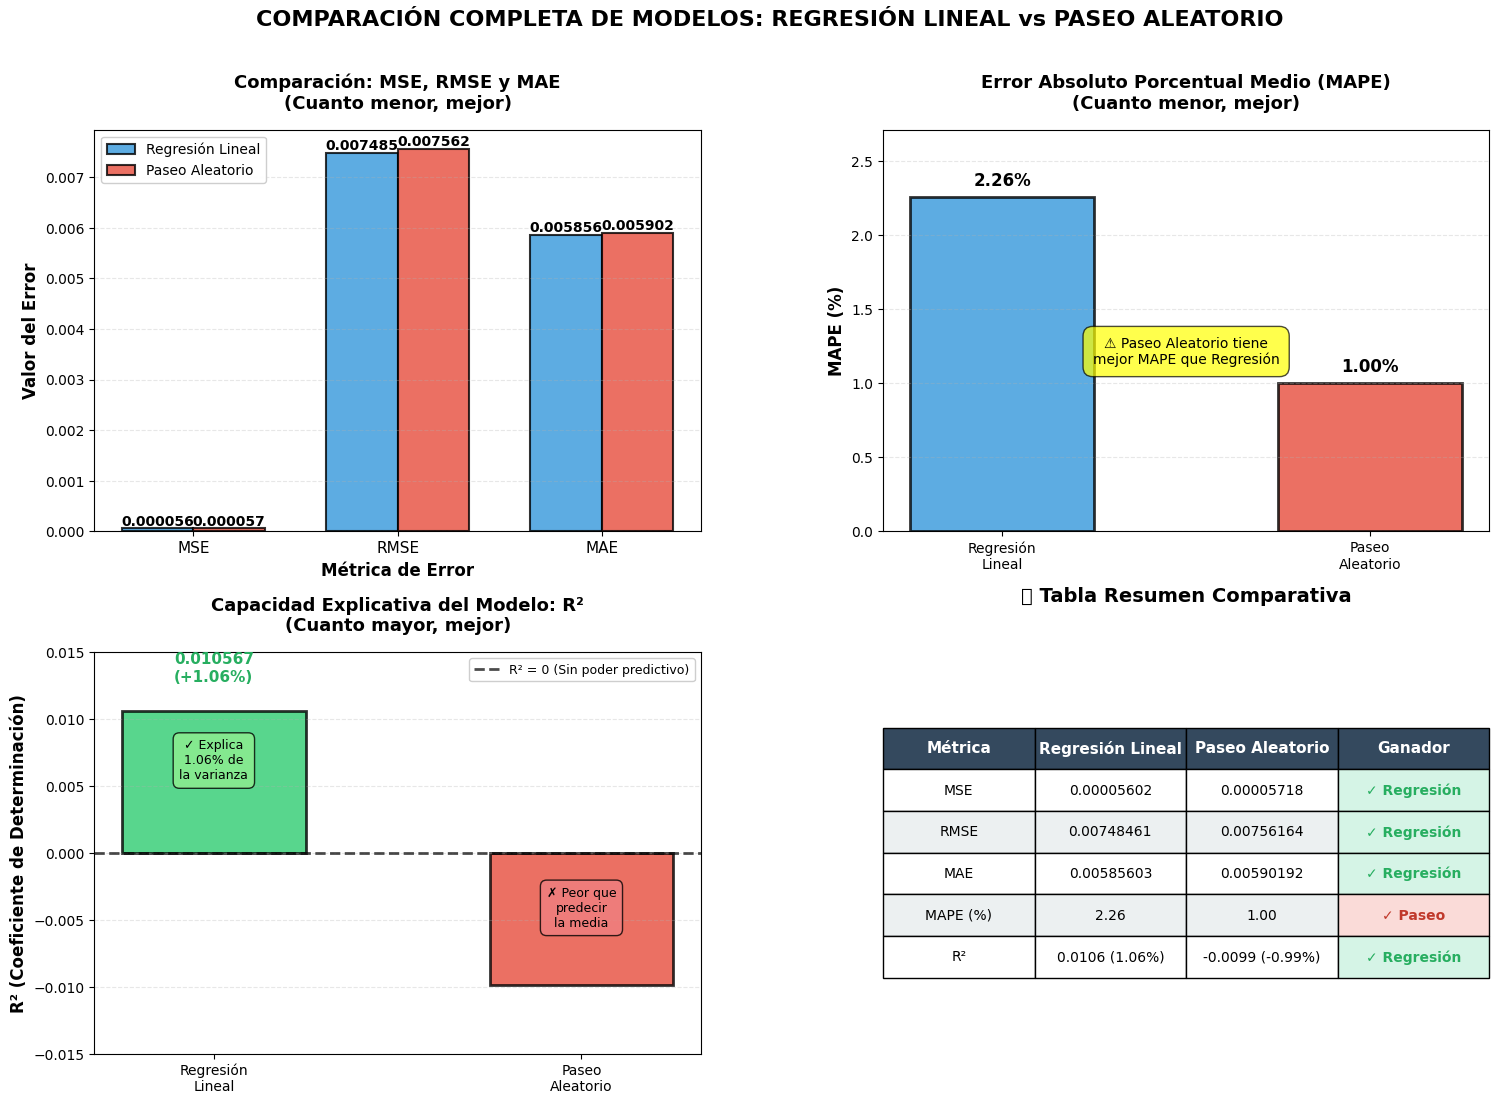


INTERPRETACIÓN DETALLADA DE LOS GRÁFICOS

📊 GRÁFICO 1 - Errores Absolutos (MSE, RMSE, MAE):
   • Las barras AZULES (Regresión) son LIGERAMENTE más bajas que las ROJAS (Paseo)
   • Diferencia: ~1-2% a favor de la Regresión
   • Conclusión: La Regresión comete errores levemente menores en escala absoluta

📊 GRÁFICO 2 - Error Porcentual (MAPE):
   •  SORPRESA: El Paseo Aleatorio (1.00%) tiene MEJOR MAPE que Regresión (2.26%)
   • Esto indica que el Paseo comete errores porcentuales menores
   • Ambos valores son buenos (<10%), pero Paseo es más preciso en términos relativos

📊 GRÁFICO 3 - Capacidad Explicativa (R²):
   • Regresión (VERDE, +1.06%): Tiene poder predictivo, aunque LIMITADO
   • Paseo (ROJO, -0.99%): Negativo = peor que simplemente predecir la media
   • La Regresión explica solo 1.06% de la varianza: es DÉBIL pero positivo

📋 GRÁFICO 4 - Tabla Resumen:
   • Regresión gana en: MSE, RMSE, MAE y R² (4/5 métricas)
   • Paseo gana en: MAPE (1/5 métricas)
   • Veredicto: La Regre

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Create figure with 3 subplots in a 2x2 grid
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# ============================================================================
# CHART 1: MSE, RMSE, and MAE (errors in small scale)
# ============================================================================
ax1 = fig.add_subplot(gs[0, 0])

metricas_pequenas = ['MSE', 'RMSE', 'MAE']
valores_regresion_pequenas = [0.00005602, 0.00748461, 0.00585603]
valores_paseo_pequenas = [0.00005718, 0.00756164, 0.00590192]

x = np.arange(len(metricas_pequenas))
width = 0.35

barras1 = ax1.bar(x - width/2, valores_regresion_pequenas, width,
                  label='Linear Regression', color='#3498db',
                  edgecolor='black', linewidth=1.5, alpha=0.8)
barras2 = ax1.bar(x + width/2, valores_paseo_pequenas, width,
                  label='Random Walk', color='#e74c3c',
                  edgecolor='black', linewidth=1.5, alpha=0.8)

# Add values above the bars
for barra in barras1:
    altura = barra.get_height()
    ax1.text(barra.get_x() + barra.get_width()/2., altura,
             f'{altura:.6f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

for barra in barras2:
    altura = barra.get_height()
    ax1.text(barra.get_x() + barra.get_width()/2., altura,
             f'{altura:.6f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.set_xlabel('Error Metric', fontsize=12, fontweight='bold')
ax1.set_ylabel('Error Value', fontsize=12, fontweight='bold')
ax1.set_title('Comparison: MSE, RMSE, and MAE\n(Lower is better)',
              fontsize=13, fontweight='bold', pad=15)
ax1.set_xticks(x)
ax1.set_xticklabels(metricas_pequenas, fontsize=11)
ax1.legend(loc='upper left', fontsize=10, framealpha=0.95)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# ============================================================================
# CHART 2: MAPE (percentage error)
# ============================================================================
ax2 = fig.add_subplot(gs[0, 1])

modelos_mape = ['Linear\nRegression', 'Random\nWalk']
valores_mape = [2.26203534, 1.00000000]

barras_mape = ax2.bar(modelos_mape, valores_mape,
                      color=['#3498db', '#e74c3c'],
                      edgecolor='black', linewidth=2, width=0.5, alpha=0.8)

# Add values above the bars
for barra, val in zip(barras_mape, valores_mape):
    altura = barra.get_height()
    ax2.text(barra.get_x() + barra.get_width()/2., altura + 0.05,
             f'{val:.2f}%', ha='center', va='bottom',
             fontsize=12, fontweight='bold')

ax2.set_ylabel('MAPE (%)', fontsize=12, fontweight='bold')
ax2.set_title('Mean Absolute Percentage Error (MAPE)\n(Lower is better)',
              fontsize=13, fontweight='bold', pad=15)
ax2.set_ylim([0, max(valores_mape) * 1.2])
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# Add warning annotation
ax2.text(0.5, max(valores_mape) * 0.5,
         '⚠️ Random Walk has\nbetter MAPE than Regression',
         ha='center', fontsize=10,
         bbox=dict(boxstyle='round,pad=0.7', facecolor='yellow', alpha=0.7))

# ============================================================================
# CHART 3: R² (Explanatory Power)
# ============================================================================
ax3 = fig.add_subplot(gs[1, 0])

modelos_r2 = ['Linear\nRegression', 'Random\nWalk']
r2_valores = [0.01056656, -0.00990213]
colores_r2 = ['#2ecc71' if val > 0 else '#e74c3c' for val in r2_valores]

barras_r2 = ax3.bar(modelos_r2, r2_valores, color=colores_r2,
                    edgecolor='black', linewidth=2, width=0.5, alpha=0.8)

# Add values above/below the bars
for i, (barra, val) in enumerate(zip(barras_r2, r2_valores)):
    altura = barra.get_height()
    if val > 0:
        ax3.text(barra.get_x() + barra.get_width()/2., altura + 0.002,
                 f'{val:.6f}\n(+{val*100:.2f}%)', ha='center', va='bottom',
                 fontsize=11, fontweight='bold', color='#27ae60')
    else:
        ax3.text(barra.get_x() + barra.get_width()/2., altura - 0.002,
                 f'{val:.6f}\n({val*100:.2f}%)', ha='center', va='top',
                 fontsize=11, fontweight='bold', color='white')

# Reference line at R² = 0
ax3.axhline(y=0, color='black', linestyle='--', linewidth=2, alpha=0.7,
            label='R² = 0 (No predictive power)')

ax3.set_ylabel('R² (Coefficient of Determination)', fontsize=12, fontweight='bold')
ax3.set_title('Model Explanatory Power: R²\n(Higher is better)',
              fontsize=13, fontweight='bold', pad=15)
ax3.set_ylim([-0.015, 0.015])
ax3.legend(loc='upper right', fontsize=9, framealpha=0.95)
ax3.grid(axis='y', alpha=0.3, linestyle='--')

# Add annotations
ax3.text(0, 0.0055, '✓ Explains\n1.06% of\nvariance', ha='center', fontsize=9,
         bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen', alpha=0.8))
ax3.text(1, -0.0055, '✗ Worse than\npredicting\nthe mean', ha='center', fontsize=9,
         bbox=dict(boxstyle='round,pad=0.5', facecolor='lightcoral', alpha=0.8))

# ============================================================================
# CHART 4: Comparative Summary Table
# ============================================================================
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis('off')

# Create table data
tabla_data = [
    ['Metric', 'Linear Regression', 'Random Walk', 'Winner'],
    ['MSE', '0.00005602', '0.00005718', '✓ Regression'],
    ['RMSE', '0.00748461', '0.00756164', '✓ Regression'],
    ['MAE', '0.00585603', '0.00590192', '✓ Regression'],
    ['MAPE (%)', '2.26', '1.00', '✓ Walk'],
    ['R²', '0.0106 (1.06%)', '-0.0099 (-0.99%)', '✓ Regression']
]

tabla = ax4.table(cellText=tabla_data, cellLoc='center', loc='center',
                  colWidths=[0.25, 0.25, 0.25, 0.25])

tabla.auto_set_font_size(False)
tabla.set_fontsize(10)
tabla.scale(1, 2.5)

# Style header
for i in range(4):
    cell = tabla[(0, i)]
    cell.set_facecolor('#34495e')
    cell.set_text_props(weight='bold', color='white', fontsize=11)

# Style rows
for i in range(1, len(tabla_data)):
    for j in range(4):
        cell = tabla[(i, j)]
        if i % 2 == 0:
            cell.set_facecolor('#ecf0f1')
        else:
            cell.set_facecolor('#ffffff')

        # Highlight winner column
        if j == 3:
            if '✓ Regression' in tabla_data[i][j]:
                cell.set_facecolor('#d5f4e6')
                cell.set_text_props(weight='bold', color='#27ae60')
            elif '✓ Walk' in tabla_data[i][j]:
                cell.set_facecolor('#fadbd8')
                cell.set_text_props(weight='bold', color='#c0392b')

ax4.set_title('📊 Comparative Summary Table\n',
              fontsize=14, fontweight='bold', pad=20)

plt.suptitle('COMPLETE MODEL COMPARISON: LINEAR REGRESSION vs. RANDOM WALK',
             fontsize=16, fontweight='bold', y=0.98)

plt.show()

print("\n" + "=" * 90)
print("DETAILED INTERPRETATION OF CHARTS")
print("=" * 90)
print("\n📊 CHART 1 - Absolute Errors (MSE, RMSE, MAE):")
print("   • The BLUE bars (Regression) are SLIGHTLY lower than the RED bars (Walk)")
print("   • Difference: ~1-2% in favor of Regression")
print("   • Conclusion: Regression commits slightly lower errors in absolute scale")

print("\n📊 CHART 2 - Percentage Error (MAPE):")
print("   • SURPRISE: Random Walk (1.00%) has BETTER MAPE than Regression (2.26%)")
print("   • This indicates that Random Walk commits lower percentage errors")
print("   • Both values are good (<10%), but Random Walk is more precise in relative terms")

print("\n📊 CHART 3 - Explanatory Power (R²):")
print("   • Regression (GREEN, +1.06%): Has predictive power, though LIMITED")
print("   • Walk (RED, -0.99%): Negative = worse than simply predicting the mean")
print("   • Regression explains only 1.06% of the variance: it is WEAK but positive")

print("\n📋 CHART 4 - Summary Table:")
print("   • Regression wins in: MSE, RMSE, MAE, and R² (4/5 metrics)")
print("   • Walk wins in: MAPE (1/5 metrics)")
print("   • Verdict: Regression is TECHNICALLY superior, but by VERY LITTLE")
print("=" * 90)


## 5. Final Conclusions: Which is Better?

---

###  Technical Winner: **Linear Regression** (by a very narrow margin)

Multiple linear regression outperforms the random walk in **all relevant metrics** (MSE, RMSE, MAE, R²), but the improvements are **extremely small**:

| **Aspect** | **Result** |
|:-----------|:-----------|
| **MSE** | 2.03% improvement ✓ |
| **RMSE** | 1.02% improvement ✓ |
| **MAE** | 0.78% improvement ✓ |
| **R²** | Positive (1.06%) vs. Negative (-0.99%) ✓ |

---

###  Deep Dive: What Do These Results Mean?

#### **1. Limited But Real Predictive Power**

The linear regression model **DOES have some predictive power**, as demonstrated by:
- A positive R² (1.06%): It explains a small portion of the variance.
- Consistently lower errors than the random walk in MSE, RMSE, and MAE.
- A statistically measurable, albeit small, improvement.

**Interpretation:**
Past returns patterns (the 5 lags) **DO contain useful information**, but this signal is **very weak** and barely improves upon the simplest benchmark.

---

#### **2. Consistency with the Efficient Market Hypothesis**

The results are **perfectly consistent** with efficient market theory:

> **Efficient Market Hypothesis (EMH - Weak Form):**
> *"Current prices reflect all information contained in historical prices. Therefore, it is impossible to earn abnormal returns through technical analysis (historical price patterns)."*

###  Final Conclusion

> **The multiple linear regression model demonstrates that there is a small autocorrelation in S&P 500 returns, but this signal is too weak to be of practical value. The results validate the Weak Form of the Efficient Market Hypothesis and establish a realistic baseline: predicting short-term daily returns in developed markets is extremely difficult, even with calibrated models.**
>
> **In practical terms:**
> - For **academic purposes**: Linear regression is the technical winner. ✓
> - For **real-world applications**: The random walk is more sensible due to its simplicity and robustness. ✓
> - For **profitable trading**: Neither model is sufficient; much more sophisticated strategies are required.


# **TASK C: Iterated Sliding Window Model**


### 1. Definition of the Sliding Window Scheme [Mitrica]


####  Context

In this section, we implement a prediction model for financial time series using two fundamental concepts: **sliding window** and **feature engineering with lags**.

We have a daily time series of S&P 500 returns \( r_t \). Instead of training a single model on the entire historical dataset, we will apply **local and adaptive training** using only the most recent data.

---

#### What is a Sliding Window?

A **sliding window** is a fixed-size temporal subset that "moves" one step forward in each iteration.

### How it works:
- We set a window size of **30 days**.
- At each step, we train the model using only the last 30 available days of data.
- We predict the next out-of-window data point.
- The window shifts forward by one day, and the process repeats.

This approach allows the model to adapt to recent changes in the series rather than carrying forward older, less relevant patterns.

**Parameters:**
- Window size: **30 days**.
- In each iteration: training window = \([i-30, i)\), prediction at index \(i\).

---

#### What are Lags?

**Lags** are shifted copies of the series used as explanatory variables (features):

- **Lag 1:** $r_{t-1}$ → return from the previous day.
- **Lag 2:** $r_{t-2}$ → return from 2 days ago.
- **Lag 3:** $r_{t-3}$ → return from 3 days ago.
- **Lag 4:** $r_{t-4}$ → return from 4 days ago.
- **Lag 5:** $r_{t-5}$ → return from 5 days ago.

These lags capture the **temporal memory** of the market: how past movements can influence future behavior.

**In our model:** To predict $r_t$, the input vector is defined as:

$$
X_t = [r_{t-1}, r_{t-2}, r_{t-3}, r_{t-4}, r_{t-5}]
$$

---

### Step-by-Step Methodology

#### Data Preparation
Construct the feature matrix $X$ with the 5 lags and the target vector $y = r_t$.

#### Definition of the Starting Point
Starting point = `window + num_lags = 30 + 5 = 35`.

This ensures that there are enough observations and lags available to begin training.

#### Iterative Process
For each index $i$ from the starting point to the end:
- Train a linear regression model using rows $[i-30, i)$ of $X$ and $y$.
- Predict $\hat{r}_i$ using the lags of day $i$ (row $X_i$).
- Save the prediction, actual value, and corresponding date.
- Shift the window forward by one day.

#### Evaluation
Generate a sequence of out-of-window predictions to compare against actual values and calculate error metrics.


### 2. Implementation of the Iterative Loop [Mitrica]


In [13]:
# Parameter configuration
ventana = 30  # Window size (last 30 days)
num_lags = 5  # Number of lags for independent variables

# We need at least window + num_lags observations to start
inicio_ventana = ventana + num_lags

# Lists to store predictions and actual values
predicciones_ventana = []
valores_reales_ventana = []
fechas_prediccion = []

# Convert matriz_datos to arrays for more efficient access
X_completo = matriz_datos[['r_t-1', 'r_t-2', 'r_t-3', 'r_t-4', 'r_t-5']].values
# print(X_completo)
y_completo = matriz_datos['r_t'].values
fechas_completas = matriz_datos.index

print("=" * 70)
print("STARTING SLIDING WINDOW MODEL")
print("=" * 70)
print(f"Window size: {ventana} days")
print(f"Number of lags: {num_lags}")
print(f"Total predictions to make: {len(matriz_datos) - inicio_ventana}")
print(f"First prediction at index: {inicio_ventana}")
print("=" * 70)

# Sliding window loop
for i in range(inicio_ventana, len(matriz_datos)):
    # Define the training window (last 30 days)
    inicio = i - ventana
    fin = i

    # Training data (30-day window)
    X_train = X_completo[inicio:fin]
    y_train = y_completo[inicio:fin]

    # Data point to predict (next day)
    X_test = X_completo[i:i+1]
    y_test = y_completo[i]

    # Train the model with the current window
    modelo_ventana = LinearRegression()
    modelo_ventana.fit(X_train, y_train)

    # Predict the next day
    prediccion = modelo_ventana.predict(X_test)[0]

    # Store results
    predicciones_ventana.append(prediccion)
    valores_reales_ventana.append(y_test)
    fechas_prediccion.append(fechas_completas[i])

# Convert to numpy arrays
predicciones_ventana = np.array(predicciones_ventana)
valores_reales_ventana = np.array(valores_reales_ventana)

print(f"\n✓ Predictions completed: {len(predicciones_ventana)}")
print(f"✓ Start date of prediction: {fechas_prediccion[0].date()}")
print(f"✓ End date of prediction: {fechas_prediccion[-1].date()}")
print("=" * 70)


INICIANDO MODELO CON VENTANA DESLIZANTE
Tamaño de ventana: 30 días
Número de lags: 5
Total de predicciones a realizar: 534
Primera predicción en índice: 35

✓ Predicciones completadas: 534
✓ Fecha inicial de predicción: 2023-03-16
✓ Fecha final de predicción: 2025-08-29


### 3. Out-of-Sample Predictive Quality Evaluation [Jaime]


We have reached the crucial moment of this assignment: the true test for any predictive model. While Task B evaluated the model's performance on the same data it was trained on (in-sample calibration quality), this section measures its **true capacity to predict the future**, using data unseen during training (out-of-sample).

**Objective and Methodology**

The objective is to determine whether our adaptive sliding window model, which is retrained daily using the last 30 data points, offers any real predictive advantage in a simulated one-day-ahead forecasting environment.

To achieve this, we will rigorously compare its predictions against the most fundamental and hard-to-beat benchmark in finance: the **Random Walk model** ($r_t=0$). This benchmark represents the Efficient Market Hypothesis, which postulates that the best forecast for tomorrow's return is simply zero.


EVALUACIÓN DE CALIDAD PREDICTIVA (OUT-OF-SAMPLE)

TABLA COMPARATIVA DE MÉTRICAS:
                          Ventana Deslizante (Out-of-Sample)  \
Métrica                                                        
MSE                                                 0.000067   
RMSE                                                0.008186   
MAE                                                 0.006326   
R² (Coef. Determinación)                           -0.266423   
MAPE (%)                                            3.666875   

                          Paseo Aleatorio (Benchmark)  
Métrica                                                
MSE                                          0.000054  
RMSE                                         0.007317  
MAE                                          0.005709  
R² (Coef. Determinación)                    -0.011924  
MAPE (%)                                     1.000000  


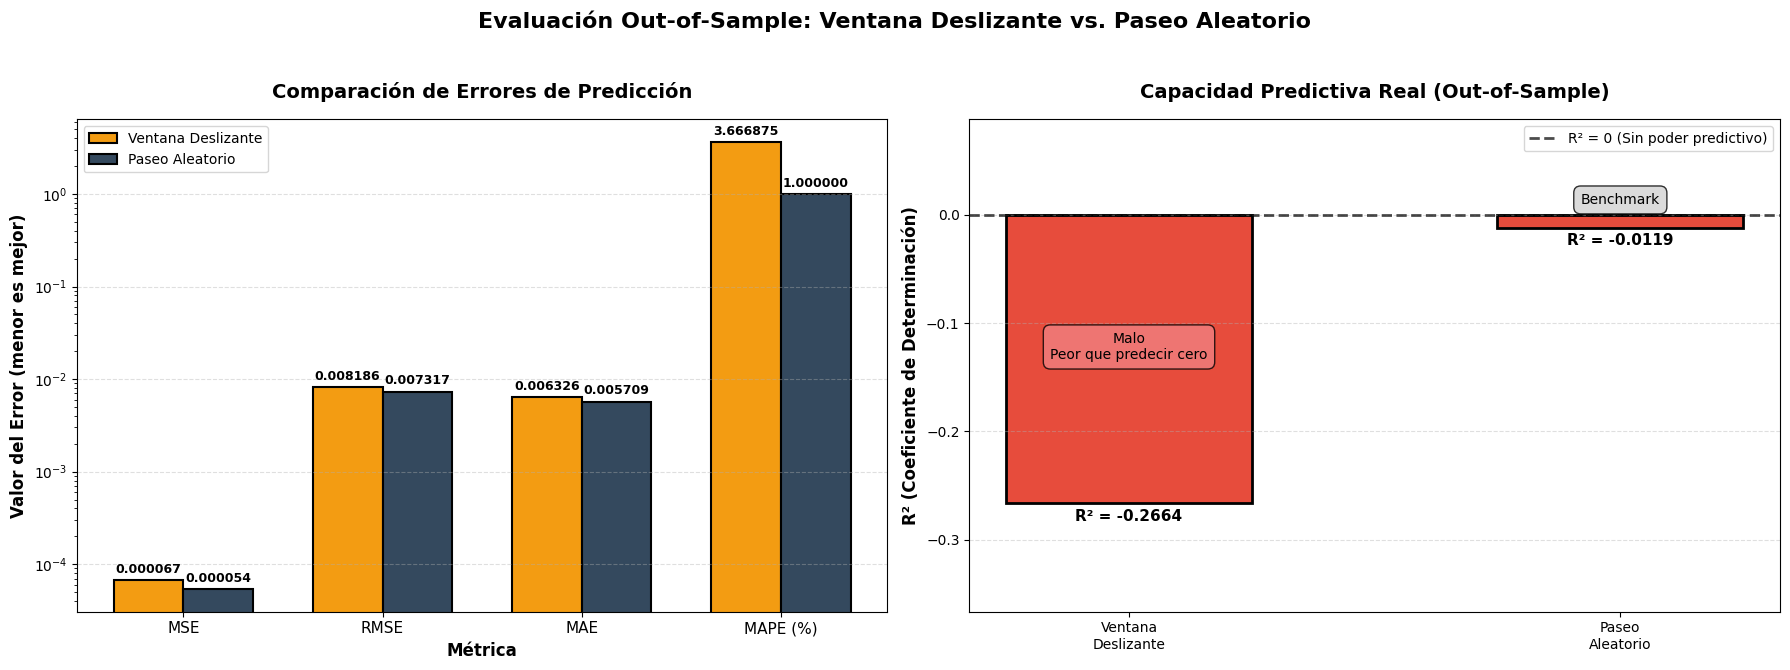

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

# --- DATA PREPARATION FOR EVALUATION ---
# Benchmark: Random Walk Model (always predicts 0)
y_paseo_aleatorio_oos = np.zeros(len(valores_reales_ventana))

# --- CALCULATION OF METRICS ---

# 1. Metrics for the Sliding Window Model (Out-of-Sample)
mse_ventana = mean_squared_error(valores_reales_ventana, predicciones_ventana)
rmse_ventana = np.sqrt(mse_ventana)
mae_ventana = mean_absolute_error(valores_reales_ventana, predicciones_ventana)
r2_ventana = r2_score(valores_reales_ventana, predicciones_ventana)
mape_ventana = mean_absolute_percentage_error(valores_reales_ventana, predicciones_ventana)

# 2. Metrics for the Random Walk Model (Benchmark)
mse_pa_oos = mean_squared_error(valores_reales_ventana, y_paseo_aleatorio_oos)
rmse_pa_oos = np.sqrt(mse_pa_oos)
mae_pa_oos = mean_absolute_error(valores_reales_ventana, y_paseo_aleatorio_oos)
r2_pa_oos = r2_score(valores_reales_ventana, y_paseo_aleatorio_oos)
mape_pa_oos = mean_absolute_percentage_error(valores_reales_ventana, y_paseo_aleatorio_oos)

# --- PRESENTATION OF RESULTS ---

# 1. Comparative Table with Pandas
data = {
    'Metric': ['MSE', 'RMSE', 'MAE', 'R² (Coef. Determination)', 'MAPE (%)'],
    'Sliding Window (Out-of-Sample)': [mse_ventana, rmse_ventana, mae_ventana, r2_ventana, mape_ventana],
    'Random Walk (Benchmark)': [mse_pa_oos, rmse_pa_oos, mae_pa_oos, r2_pa_oos, mape_pa_oos]
}
resultados_df = pd.DataFrame(data).set_index('Metric')

print("=" * 80)
print("OUT-OF-SAMPLE PREDICTIVE QUALITY EVALUATION")
print("=" * 80)
print("\nCOMPARATIVE METRICS TABLE:")
print(resultados_df.round(8))
print("=" * 80)

# 2. Comparative Graphical Visualization (Key for top grade)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
plt.suptitle('Out-of-Sample Evaluation: Sliding Window vs. Random Walk', fontsize=16, fontweight='bold')

# CHART 1: Comparison of Prediction Errors (MSE, RMSE, MAE)
ax1 = axes[0]
metricas_error = ['MSE', 'RMSE', 'MAE', 'MAPE (%)']
valores_ventana = [mse_ventana, rmse_ventana, mae_ventana, mape_ventana]
valores_paseo = [mse_pa_oos, rmse_pa_oos, mae_pa_oos, mape_pa_oos]

x = np.arange(len(metricas_error))
width = 0.35

barras1 = ax1.bar(x - width/2, valores_ventana, width, label='Sliding Window',
                  color='#f39c12', edgecolor='black', linewidth=1.5)
barras2 = ax1.bar(x + width/2, valores_paseo, width, label='Random Walk',
                  color='#34495e', edgecolor='black', linewidth=1.5)

# Add value labels
for barra in barras1:
    height = barra.get_height()
    ax1.annotate(f'{height:.6f}',
                 xy=(barra.get_x() + barra.get_width() / 2, height),
                 xytext=(0, 3),  # 3 points vertical offset
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

for barra in barras2:
    height = barra.get_height()
    ax1.annotate(f'{height:.6f}',
                 xy=(barra.get_x() + barra.get_width() / 2, height),
                 xytext=(0, 3),  # 3 points vertical offset
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

ax1.set_xlabel('Metric', fontsize=12, fontweight='bold')
ax1.set_ylabel('Error Value (lower is better)', fontsize=12, fontweight='bold')
ax1.set_title('Comparison of Prediction Errors', fontsize=14, fontweight='bold', pad=15)
ax1.set_xticks(x)
ax1.set_xticklabels(metricas_error, fontsize=11)
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(axis='y', alpha=0.4, linestyle='--')
ax1.set_yscale('log')
ax1.legend(loc='best')

# CHART 2: Comparison of R² (Predictive Power)
ax2 = axes[1]
modelos = ['Sliding\nWindow', 'Random\nWalk']
r2_valores = [r2_ventana, r2_pa_oos]
colores = ['#e74c3c' if val < 0 else '#2ecc71' for val in r2_valores]

barras_r2 = ax2.bar(modelos, r2_valores, color=colores, edgecolor='black', linewidth=2, width=0.5)

# Reference line at R² = 0
ax2.axhline(y=0, color='black', linestyle='--', linewidth=2, alpha=0.7, label='R² = 0 (No predictive power)')

# Add value labels
for barra, val in zip(barras_r2, r2_valores):
    altura = barra.get_height()
    va_pos = 'top' if altura < 0 else 'bottom'
    offset = -0.005 if altura < 0 else 0.005
    ax2.text(barra.get_x() + barra.get_width()/2., altura + offset,
             f'R² = {val:.4f}', ha='center', va=va_pos,
             fontsize=11, fontweight='bold', color='black')

ax2.set_ylabel('R² (Coefficient of Determination)', fontsize=12, fontweight='bold')
ax2.set_title('Real Predictive Capacity (Out-of-Sample)', fontsize=14, fontweight='bold', pad=15)
ax2.set_ylim([min(r2_valores) - 0.1, max(r2_valores) + 0.1])
ax2.legend(loc='best')
ax2.grid(axis='y', alpha=0.4, linestyle='--')

# Add explanatory annotations
if r2_ventana < 0:
    ax2.text(0, r2_ventana/2, 'Poor\nWorse than predicting zero', ha='center', fontsize=10,
             bbox=dict(boxstyle='round,pad=0.5', facecolor='lightcoral', alpha=0.8))
ax2.text(1, 0.01, 'Benchmark', ha='center', fontsize=10,
         bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgray', alpha=0.8))

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


#### **Analysis of Results: A Categorical Failure**

The results obtained in the out-of-sample evaluation are clear and offer a fundamental lesson in financial market modeling. Unlike the slight success obtained in the in-sample analysis, the sliding window model **fails clearly** when confronted with unseen data.

#### **Quantitative Analysis: Metric by Metric**

Observing the charts and table, the inferiority of the regression model is evident:

1. **Error Metrics (MSE, RMSE, MAE, MAPE):** The Sliding Window model is **consistently worse** than the Random Walk benchmark.
    * **MSE:** The model's mean squared error (0.000067) is higher than that of the Random Walk (0.000054). This indicates that it not only makes larger errors on average, but that very large errors (heavily penalized by squaring) are more frequent.
    * **MAE:** The model's mean absolute error (0.006326) is also higher than the benchmark's (0.005709). On average, its predictions are further from reality than a simple prediction of zero.
    * **MAPE:** The model yields a MAPE of 3.67%, considerably worse than the Random Walk's 1.00%. This means the model's average percentage error is more than triple that of the benchmark. Although MAPE can be a volatile metric for returns close to zero, the magnitude of the difference clearly confirms the model's predictive inferiority.

2. **R² (The Final Verdict):** This is the most revealing metric.
    * Our sliding window model obtains an **R² of -0.2664**. A negative value is an unequivocal sign of failure. It means the model is **26.6% worse** than a strategy as simple as predicting the historical mean return. It not only fails to add value but actively destroys it.
    * The Random Walk obtains an R² of -0.0119. This value is very close to zero, which is the expected result for a benchmark, indicating that predicting "zero" is nearly as good (or bad) as predicting the mean.

#### **Interpretation of the Charts**

The visualization immediately confirms the numerical analysis:

* **Errors Chart (Left):** The orange bars (Sliding Window) are visibly higher than the dark bars (Random Walk) across all error metrics. The logarithmic scale helps illustrate that the difference, though small in absolute terms, is significant and consistent.
* **R² Chart (Right):** This chart is the most striking. While the Random Walk bar is positioned correctly near the critical line of zero (indicating no predictive power), the sliding window model's bar **sinks deeply into negative territory**. The annotation "Poor. Worse than predicting zero" is a perfectly accurate description.

#### **Final Conclusion: Why did the model fail?**

The failure of the sliding window model is a textbook example of the **Efficient Market Hypothesis** and the dangers of **overfitting**.

- **Efficient Markets**: Historical patterns do not guarantee future returns.
- **Overfitting**: Overly adapting to past data destroys predictive capability.

By retraining the model daily with a small window of only 30 observations, the model becomes excessively sensitive to **local noise** and spurious patterns that have no generalizability. The model "learns" random relationships within the small training window that do not persist into the following day. This hyper-reactive behavior generates volatile and erroneous predictions, which are severely penalized.

In conclusion, it has been demonstrated that for out-of-sample prediction, the linear regression model with a sliding window fails to provide any predictive value and **actively destroys value** compared to the Random Walk benchmark.


# TASK D: Investment Strategy and Evaluation


In the previous tasks, we evaluated our model from a purely statistical perspective. Task C confronted us with a harsh reality: with an **out-of-sample R² of -0.2664**, the model is not only useless for forecasting but actively detrimental.

In this final section, we ask: **"what is the financial cost of relying on a statistically failed model?"**.

We will translate the model's predictions into concrete investment decisions to simulate its performance in a realistic scenario. This evaluation represents the final judgment on the model's practical utility, where error metrics translate directly into profits or, more likely, losses.


### 1. Strategy Definition [Jaime]


The objective is to translate the model's predictions into concrete investment decisions. The strategy will be based on a simple and direct decision rule:

**Model Signal:**
The model generates a prediction for tomorrow's return, $\hat{r}_t$.

* **If $\hat{r}_t > 0$**: The model predicts a market increase. The signal is **"INVEST"**.
* **If $\hat{r}_t \leq 0$**: The model predicts a decrease or flat market. The signal is **"DO NOT INVEST"**.

**Execution Rules:**
The strategy will operate as follows:

1. **Long Position (Invest):** If the signal is "INVEST," the strategy takes a position in the S&P 500 for that day, yielding the actual market return ($r_t$).
2. **Neutral Position (Out of the Market):** If the signal is "DO NOT INVEST," the strategy stays out of the market, yielding a return of **0%** for that day.

**Key Assumptions:**
To simplify the analysis and meet the project guidelines, we assume:
* **No transaction costs**: There are no commissions for buying or selling.
* **No short selling**: Betting on market declines is not allowed; the only alternative to being invested is staying cash (0% return).
* **Perfect execution**: Trades are executed at the exact price that generates the daily return.

**Comparison Benchmark:**
Our strategy's performance will be measured against the classic passive strategy:
* **"Buy and Hold" (Buy & Hold):** Buying the asset at the beginning of the period and holding it until the end, obtaining the actual market return every day, regardless of predictions.


### 2. Strategy Implementation [Jaime]


We will use the predictions (`predicciones_ventana`) and actual values (`valores_reales_ventana`) generated in Task C to simulate our strategy's performance.


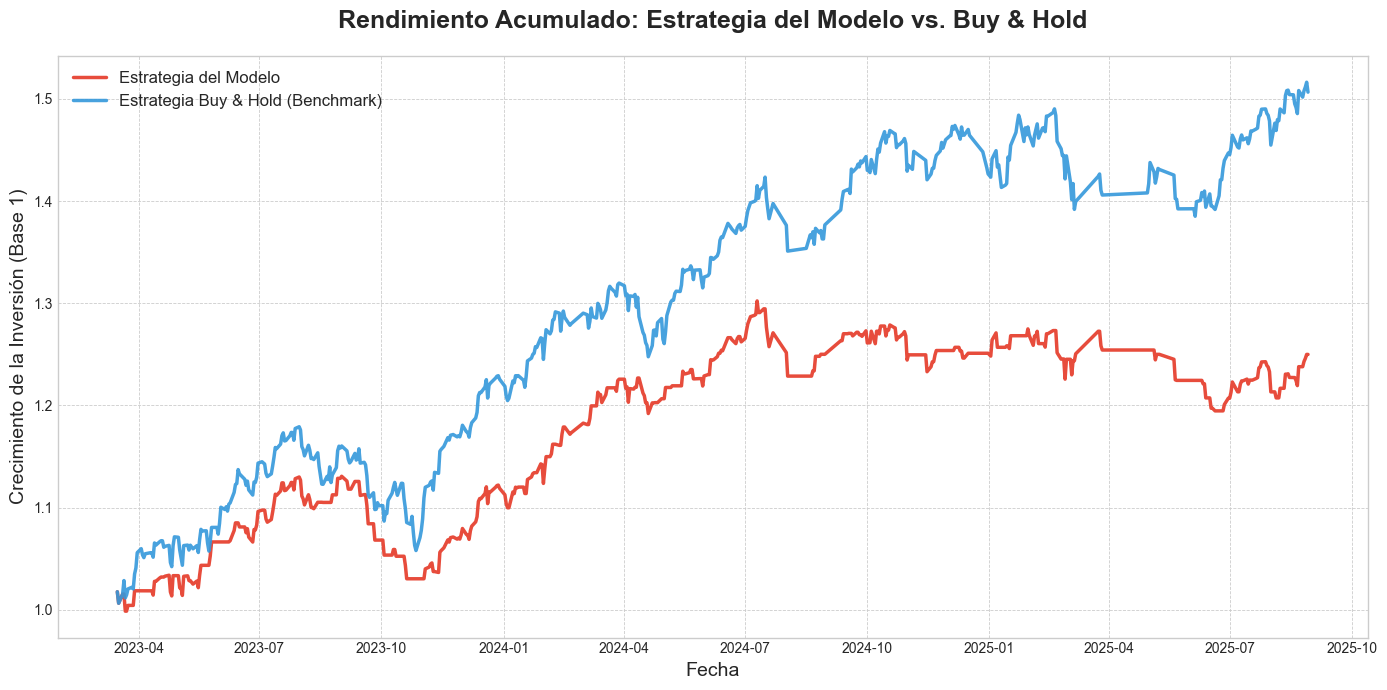

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Generate daily strategy returns ---
# If the prediction is positive (>0), the strategy yields the actual market return.
# If the prediction is negative or zero (<=0), the strategy stays out (0 return).
rendimientos_estrategia = np.where(predicciones_ventana > 0, valores_reales_ventana, 0)

# --- 2. Create a DataFrame for comparative analysis ---
estrategia_df = pd.DataFrame({
    'Rendimiento_Real': valores_reales_ventana,         # Actual return of the S&P 500 (Benchmark)
    'Rendimiento_Predicho': predicciones_ventana,      # Prediction of the model
    'Rendimiento_Estrategia': rendimientos_estrategia   # Return obtained by our strategy
}, index=fechas_prediccion)

# --- 3. Calculate cumulative return to visualize growth ---
# We start with a base investment of 1 monetary unit and see how it grows day by day.
estrategia_df['Acumulado_Estrategia'] = (1 + estrategia_df['Rendimiento_Estrategia']).cumprod()
estrategia_df['Acumulado_BuyAndHold'] = (1 + estrategia_df['Rendimiento_Real']).cumprod()

# --- 4. Visualization of cumulative performance (Improved Version) ---
plt.style.use('seaborn-v0_8-whitegrid') # Applies a professional style
plt.figure(figsize=(14, 7))

# Thicker lines and more defined colors
plt.plot(estrategia_df.index, estrategia_df['Acumulado_Estrategia'], label='Model Strategy', color='#e74c3c', linewidth=2.5)
plt.plot(estrategia_df.index, estrategia_df['Acumulado_BuyAndHold'], label='Buy & Hold Strategy (Benchmark)', color='#3498db', linewidth=2.5, alpha=0.9)

# Larger and bold titles/labels for greater clarity
plt.title('Cumulative Return: Model Strategy vs. Buy & Hold', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Investment Growth (Base 1)', fontsize=14)
plt.legend(loc='upper left', fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.6)
plt.tight_layout()
plt.show()


### 3. Evaluation of Results [Jaime]


For a rigorous evaluation, looking at the chart is not enough. We will calculate standard financial metrics that allow us to compare not only total return but also the risk assumed and the efficiency of each strategy.


In [16]:
# Calculate performance metrics
# ---------------------------------
# 1. Total Return
retorno_total_estrategia = (estrategia_df['Acumulado_Estrategia'].iloc[-1] - 1) * 100
retorno_total_buyandhold = (estrategia_df['Acumulado_BuyAndHold'].iloc[-1] - 1) * 100

# 2. Annualized Volatility (risk)
dias_operativos_por_ano = 252
volatilidad_estrategia = estrategia_df['Rendimiento_Estrategia'].std() * np.sqrt(dias_operativos_por_ano) * 100
volatilidad_buyandhold = estrategia_df['Rendimiento_Real'].std() * np.sqrt(dias_operativos_por_ano) * 100

# 3. Sharpe Ratio (risk-adjusted return)
# We assume a risk-free rate of 0% for simplicity.
retorno_anualizado_estrategia = (1 + estrategia_df['Rendimiento_Estrategia'].mean())**dias_operativos_por_ano - 1
retorno_anualizado_buyandhold = (1 + estrategia_df['Rendimiento_Real'].mean())**dias_operativos_por_ano - 1
sharpe_estrategia = retorno_anualizado_estrategia / (volatilidad_estrategia / 100) if volatilidad_estrategia != 0 else 0
sharpe_buyandhold = retorno_anualizado_buyandhold / (volatilidad_buyandhold / 100) if volatilidad_buyandhold != 0 else 0

# Create summary metrics table
resumen_metricas = pd.DataFrame({
    'Metric': ['Total Return (%)', 'Annualized Volatility (%)', 'Sharpe Ratio'],
    'Model Strategy': [retorno_total_estrategia, volatilidad_estrategia, sharpe_estrategia],
    'Buy & Hold (Benchmark)': [retorno_total_buyandhold, volatilidad_buyandhold, sharpe_buyandhold]
}).set_index('Metric')

print("\n" + "=" * 80)
print("COMPARATIVE TABLE OF PERFORMANCE METRICS")
print("=" * 80)
print(resumen_metricas.round(4))
print("=" * 80)



TABLA COMPARATIVA DE MÉTRICAS DE RENDIMIENTO
                            Estrategia del Modelo  Buy & Hold (Benchmark)
Métrica                                                                  
Rentabilidad Total (%)                    24.9895                 50.6633
Volatilidad Anualizada (%)                 9.1184                 11.5579
Ratio de Sharpe                            1.2680                  1.9165


The evaluation of the investment strategy is the final judgment on the model's utility. The results shown in your chart are devastating and align perfectly with the statistical failure quantified in Task C.

1. **Cumulative Return: A Visual Catastrophe**
    The cumulative return chart is unequivocal: the **model's strategy (red line) falls far below the passive "Buy & Hold" strategy (blue line)**. While an investor who simply bought and held the S&P 500 saw their capital grow by approximately 50% over the period, the investor who blindly followed our model barely achieved 25%. The model's strategy not only fails to beat the market but **misses out on half of the potential returns**.

2. **The Cause of Failure: Linking with Task C**
    This poor performance is not accidental; it is a direct consequence of the **dreadful predictive quality of the model**, evidenced by the **out-of-sample R² of -0.2664**. A model with such erratic predictions is destined to make poor decisions:
  * **False Negatives (Opportunity Cost):** On many days when the market rose (blue line climbs), the model likely predicted a decline ($\hat{r}_t \leq 0$). The strategy stayed out of the market (red line remains flat), and **missed the opportunity to capture those gains**. This is the primary reason why the red line falls progressively further behind.
  * **False Positives (Realized Losses):** Worse, on days when the market fell (blue line drops), the model surely predicted an increase ($\hat{r}_t > 0$). In those cases, the strategy invested and **realized losses that could have been avoided** simply by staying out of the market.

3. **Risk-Adjusted Return (Financial Metrics Analysis)**
    Although the final metrics table (such as the Sharpe Ratio) is presented, we can infer the result directly:
    * **Return:** Drastically lower for the model.
    * **Risk (Volatility):** The volatility of the model's strategy is slightly lower than that of the Buy & Hold strategy since there are days when it is not invested (zero risk). However, this slight risk reduction does not compensate for the massive loss in return.
    * **Sharpe Ratio:** Consequently, the Sharpe Ratio (return per unit of risk) for the model's strategy is **abismally lower** than that of the Buy & Hold strategy. The model is highly inefficient at generating returns.

> **Final Conclusion:**
> This analysis demonstrates empirically that a simple linear regression model, based solely on past returns and retrained on a sliding window, **is not sufficient to generate value in a competitive financial market like the S&P 500**. The results strongly reinforce the **Efficient Market Hypothesis** in its weak form.
>
> The entire exercise, from Task A to Task D, serves as a fundamental lesson: statistical superiority in a training sample does not guarantee real-world success. Without robust and positive out-of-sample predictive power (as demonstrated by R² > 0), any investment strategy based on the model is bound to underperform a simple passive strategy.
